# DX799 — Weeks 1–2 Notebook (Ordered, Enhanced)
*Generated 2025-09-24 02:57*

This notebook is ordered for smooth execution and aligned to the syllabus/rubric.
Run cells top-to-bottom.


In [ ]:
# ==============================================
# 1) CONFIG
# ==============================================

# File paths
EMISSIONS_PATH = 'emissions_medium_granularity.csv'
FUELS_PATH     = 'all_fuels_data.csv'
PIPELINE_PATH  = 'oil_Pipeline.csv'

# --- EMISSIONS ---
EM_COMPANY_COL    = 'parent_entity'
EM_YEAR_COL       = 'year'
EM_EMISSIONS_COL  = 'total_emissions_MtCO2e'
EM_PRODUCTION_COL = 'production_value'
EM_AVG_PRICE_COL  = None

# --- FUELS ---
FUEL_YEAR_COL  = 'date'   # convert to year
FUEL_PRICE_COL = 'close'  # yearly average

# --- PIPELINE ---
PIPE_DATE_OR_YEAR_COL = 'Accident Year'

# --- CV settings ---
OUTER_SPLITS = 5
INNER_SPLITS = 5
RANDOM_STATE = 42


In [ ]:
# ==============================================
# 2) DATA CHECK
# ==============================================
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.model_selection import KFold, RepeatedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
import matplotlib as mpl

# figures dir
os.makedirs('figures', exist_ok=True)

def set_viz_style():
    mpl.rcParams.update({
        'figure.dpi': 120,
        'savefig.dpi': 200,
        'figure.autolayout': True,
        'axes.grid': True,
        'grid.linestyle': '--',
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'lines.linewidth': 1.8,
        'font.size': 11,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
    })
set_viz_style()

def eval_regression(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

em_df = pd.read_csv(EMISSIONS_PATH)
fuels_df = pd.read_csv(FUELS_PATH)
pipe_df = pd.read_csv(PIPELINE_PATH)

print('EMISSIONS columns:', list(em_df.columns))
print('FUELS columns    :', list(fuels_df.columns))
print('PIPELINE columns :', list(pipe_df.columns))

if EM_YEAR_COL and not np.issubdtype(em_df[EM_YEAR_COL].dtype, np.number):
    em_df[EM_YEAR_COL] = pd.to_numeric(em_df[EM_YEAR_COL], errors='coerce')
display(em_df.head(3)); display(fuels_df.head(3)); display(pipe_df.head(3))


EMISSIONS columns: ['year', 'parent_entity', 'parent_type', 'commodity', 'production_value', 'production_unit', 'total_emissions_MtCO2e']
FUELS columns    : ['ticker', 'commodity', 'date', 'open', 'high', 'low', 'close', 'volume']
PIPELINE columns : ['Report Number', 'Supplemental Number', 'Accident Year', 'Accident Date/Time', 'Operator ID', 'Operator Name', 'Pipeline/Facility Name', 'Pipeline Location', 'Pipeline Type', 'Liquid Type', 'Liquid Subtype', 'Liquid Name', 'Accident City', 'Accident County', 'Accident State', 'Accident Latitude', 'Accident Longitude', 'Cause Category', 'Cause Subcategory', 'Unintentional Release (Barrels)', 'Intentional Release (Barrels)', 'Liquid Recovery (Barrels)', 'Net Loss (Barrels)', 'Liquid Ignition', 'Liquid Explosion', 'Pipeline Shutdown', 'Shutdown Date/Time', 'Restart Date/Time', 'Public Evacuations', 'Operator Employee Injuries', 'Operator Contractor Injuries', 'Emergency Responder Injuries', 'Other Injuries', 'Public Injuries', 'All Injuries',

,year,parent_entity,parent_type,commodity,production_value,production_unit,total_emissions_MtCO2e
0,1962,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,0.91250,Million bbl/yr,0.363885
1,1962,Abu Dhabi National Oil Company,State-owned Entity,Natural Gas,1.84325,Bcf/yr,0.134355
2,1963,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,1.82500,Million bbl/yr,0.727770


,ticker,commodity,date,open,high,low,close,volume
0,CL=F,Crude Oil,2000-08-23,31.950001,32.799999,31.950001,32.049999,79385
1,CL=F,Crude Oil,2000-08-24,31.900000,32.240002,31.400000,31.629999,72978
2,CL=F,Crude Oil,2000-08-25,31.700001,32.099998,31.320000,32.049999,44601


,Report Number,Supplemental Number,Accident Year,Accident Date/Time,Operator ID,Operator Name,Pipeline/Facility Name,Pipeline Location,Pipeline Type,Liquid Type,...,Environmental Remediation Costs,Other Costs,All Costs,Pressure (psi),Temperature (°C),Flow Rate (barrels/day),Vibration Level (mm/s),Corrosion Level (mm/year),Last Maintenance Date,Авария
0,20100016,17305.0,2010,2010-01-01 07:15:00,32109,ONEOK NGL PIPELINE LP,KINDER MORGAN JCT,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",...,0.0,0.0,1627,902.0,68.0,116820.0,1.3,0.5,2022-02-19,1.0
1,20100254,17331.0,2010,2010-01-04 08:30:00,15786,PORTLAND PIPELINE CORP,24-INCH MAIN LINE,ONSHORE,ABOVEGROUND,CRUDE OIL,...,0.0,0.0,4008,887.0,75.0,100263.0,2.4,0.3,2024-03-05,1.0
2,20100038,17747.0,2010,2010-01-05 10:30:00,20160,"PETROLOGISTICS OLEFINS, LLC",NaN,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",...,0.0,0.0,200,1057.0,63.0,102955.0,2.9,0.3,2023-08-13,1.0


In [ ]:
# ==============================================
# 3) MERGE 
# ==============================================
model_df = em_df[[EM_COMPANY_COL, EM_YEAR_COL, EM_EMISSIONS_COL]].copy()
model_df.columns = ['company', 'year', 'emissions']

if EM_PRODUCTION_COL and EM_PRODUCTION_COL in em_df.columns:
    tmp = em_df[[EM_COMPANY_COL, EM_YEAR_COL, EM_PRODUCTION_COL]].copy()
    tmp.columns = ['company', 'year', 'production']
    model_df = model_df.merge(tmp, on=['company','year'], how='left')
else:
    print('error')

# FUELS → avg_price per year
if FUEL_YEAR_COL in fuels_df.columns:
    if not np.issubdtype(fuels_df[FUEL_YEAR_COL].dtype, np.number):
        fuels_df[FUEL_YEAR_COL] = pd.to_datetime(fuels_df[FUEL_YEAR_COL], errors='coerce').dt.year
    price_df = fuels_df[[FUEL_YEAR_COL, FUEL_PRICE_COL]].copy()
    price_df = price_df.groupby(FUEL_YEAR_COL, as_index=False)[FUEL_PRICE_COL].mean()
    price_df.columns = ['year','avg_price']
    model_df = model_df.merge(price_df, on='year', how='left')
else:
    print('error')

# PIPELINE → incident_count per year
if PIPE_DATE_OR_YEAR_COL in pipe_df.columns:
    inc_df = pipe_df.groupby(PIPE_DATE_OR_YEAR_COL).size().reset_index(name='incident_count')
    inc_df.columns = ['year','incident_count']
    if not np.issubdtype(inc_df['year'].dtype, np.number):
        inc_df['year'] = pd.to_numeric(inc_df['year'], errors='coerce')
    model_df = model_df.merge(inc_df, on='year', how='left')
else:
    print('error')

for col in ['emissions','production','avg_price','incident_count']:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce')
model_df = model_df.dropna(subset=['emissions']).reset_index(drop=True)
print('Modeling table shape:', model_df.shape)
display(model_df.head(10))
model_df.head(50).to_csv('figures/model_df_preview.csv', index=False)


Modeling table shape: (30921, 6)


,company,year,emissions,production,avg_price,incident_count
0,Abu Dhabi National Oil Company,1962,0.363885,0.91250,NaN,NaN
1,Abu Dhabi National Oil Company,1962,0.363885,1.84325,NaN,NaN
2,Abu Dhabi National Oil Company,1962,0.134355,0.91250,NaN,NaN
3,Abu Dhabi National Oil Company,1962,0.134355,1.84325,NaN,NaN
4,Abu Dhabi National Oil Company,1963,0.727770,1.82500,NaN,NaN
5,Abu Dhabi National Oil Company,1963,0.727770,4.42380,NaN,NaN
6,Abu Dhabi National Oil Company,1963,0.322453,1.82500,NaN,NaN
7,Abu Dhabi National Oil Company,1963,0.322453,4.42380,NaN,NaN
8,Abu Dhabi National Oil Company,1964,2.911079,7.30000,NaN,NaN
9,Abu Dhabi National Oil Company,1964,2.911079,17.32655,NaN,NaN


emissions         0.000000
production        0.000000
avg_price         0.603829
incident_count    0.771320
Name: NaN_rate, dtype: float64

,emissions,production,avg_price,incident_count
year,,,,
1854,0.0,0.0,1.0,1.0
1855,0.0,0.0,1.0,1.0
1856,0.0,0.0,1.0,1.0
1857,0.0,0.0,1.0,1.0
1858,0.0,0.0,1.0,1.0


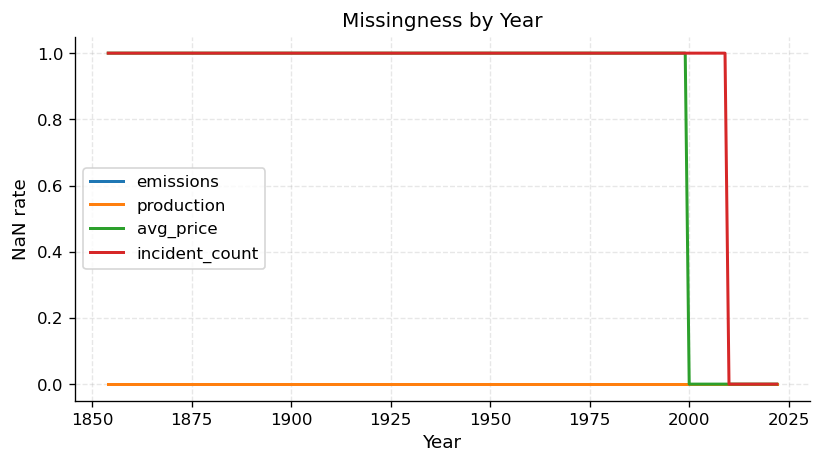

In [ ]:
# ==============================================
# 3A) EDA 
# ==============================================
import numpy as np
key_cols = ['emissions','production','avg_price','incident_count']
miss_overall = model_df[key_cols].isna().mean().rename('NaN_rate')
display(miss_overall)
miss_overall.to_csv('figures/eda_missing_overall.csv')
miss_year = model_df.groupby('year')[key_cols].apply(lambda df: df.isna().mean())
display(miss_year.head())
miss_year.to_csv('figures/eda_missing_by_year.csv')
set_viz_style(); plt.figure(figsize=(7,4))
for c in key_cols:
    if c in model_df.columns:
        plt.plot(miss_year.index, miss_year[c], label=c)
plt.xlabel('Year'); plt.ylabel('NaN rate'); plt.title('Missingness by Year'); plt.legend()
plt.tight_layout(); plt.savefig('figures/eda_missing_by_year.png', dpi=200, bbox_inches='tight'); plt.show()


In [ ]:
# ==============================================
# 3B) EDA 
# ==============================================
if 'production_unit' in em_df.columns:
    unit_counts = em_df['production_unit'].value_counts(dropna=False)
    display(unit_counts.head(10))
    unit_counts.to_csv('figures/eda_production_units_counts.csv')
if 'commodity' in em_df.columns:
    commodity_counts = em_df['commodity'].value_counts().head(15)
    display(commodity_counts)
    commodity_counts.to_csv('figures/eda_commodity_counts.csv')


production_unit
Million tonnes/yr     5103
Million bbl/yr        3733
Bcf/yr                3452
Million Tonnes CO2     263
Name: count, dtype: int64

commodity
Oil & NGL              3733
Natural Gas            3452
Bituminous Coal        1370
Metallurgical Coal     1073
Lignite Coal           1008
Sub-Bituminous Coal     673
Thermal Coal            611
Anthracite Coal         368
Cement                  263
Name: count, dtype: int64

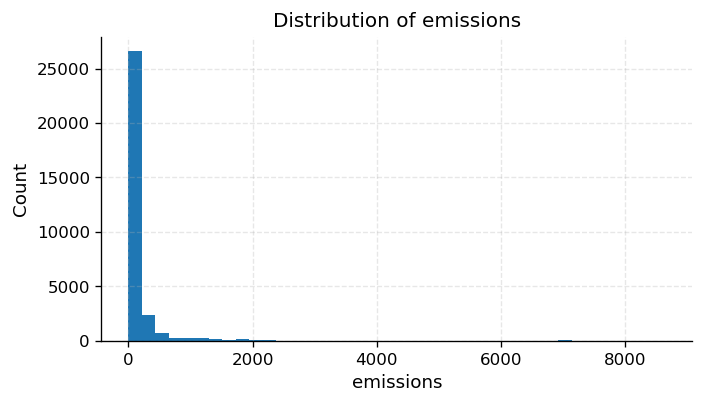

emissions: IQR outlier rate ~ 0.113 (lo=-149.70, hi=273.49)


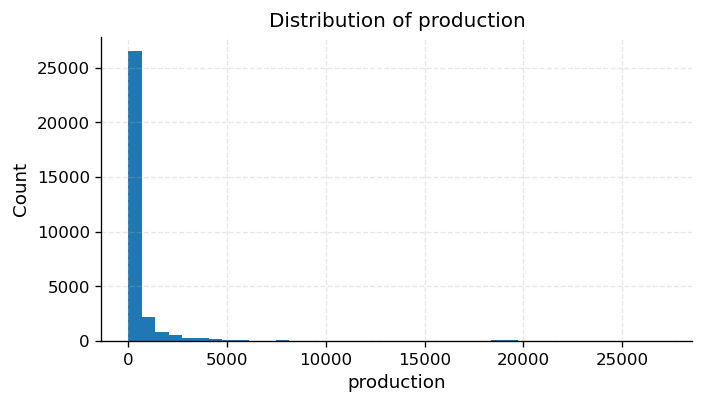

production: IQR outlier rate ~ 0.141 (lo=-398.21, hi=687.44)


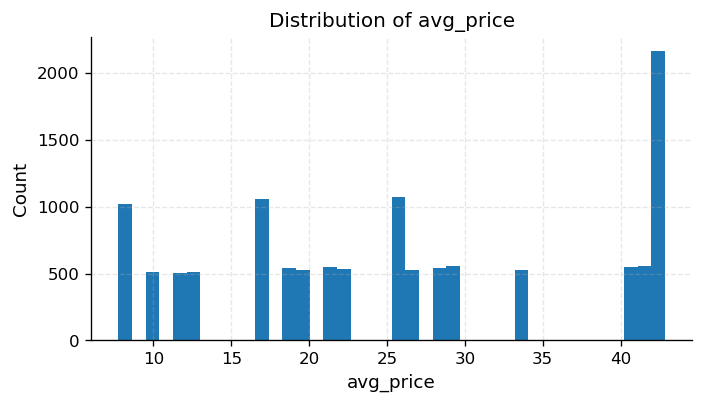

avg_price: IQR outlier rate ~ 0.000 (lo=-17.30, hi=74.83)


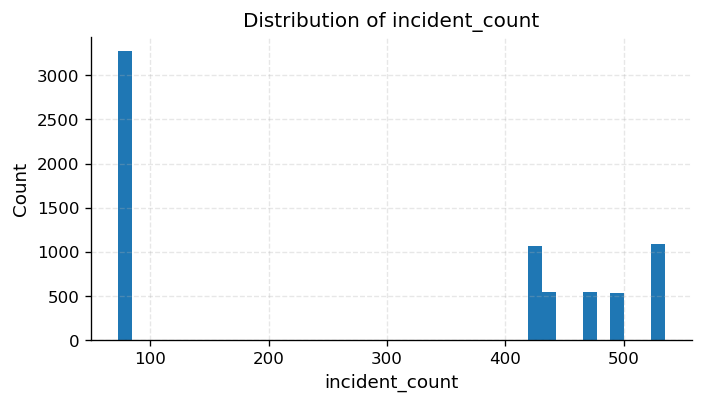

incident_count: IQR outlier rate ~ 0.000 (lo=-510.00, hi=1066.00)


In [ ]:
# ==============================================
# 3C) EDA — Distributions
# ==============================================
import numpy as np
numeric = [c for c in ['emissions','production','avg_price','incident_count'] if c in model_df.columns]
for c in numeric:
    series = model_df[c].dropna()
    set_viz_style(); plt.figure(figsize=(6,3.5))
    plt.hist(series, bins=40)
    plt.title(f'Distribution of {c}')
    plt.xlabel(c); plt.ylabel('Count')
    plt.tight_layout(); plt.savefig(f'figures/eda_dist_{c}.png', dpi=200, bbox_inches='tight'); plt.show()
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out_rate = float(((series < lo) | (series > hi)).mean())
    print(f'{c}: IQR outlier rate ~ {out_rate:.3f} (lo={lo:.2f}, hi={hi:.2f})')


,emissions,production,avg_price,incident_count
year,,,,
1854,0.033066,0.017002,NaN,NaN
1855,0.042999,0.022109,NaN,NaN
1856,0.052931,0.027216,NaN,NaN
1857,0.061527,0.031635,NaN,NaN
1858,0.070122,0.036055,NaN,NaN


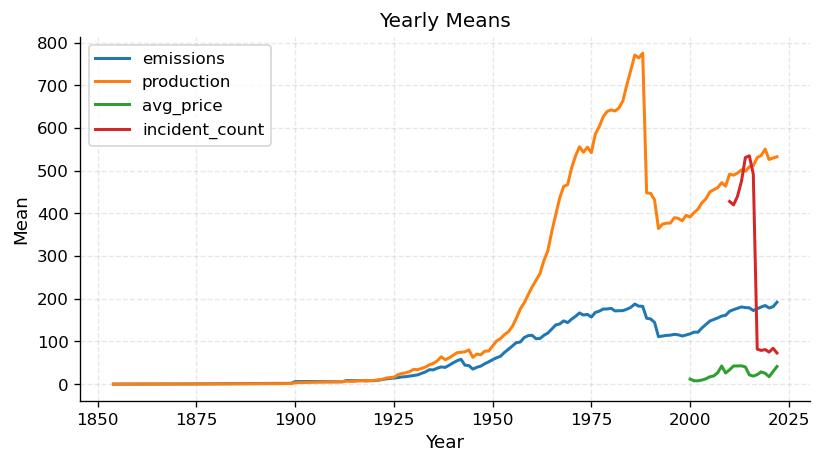

In [ ]:
# ==============================================
# 3D) EDA — Yearly trends
# ==============================================
numeric = [c for c in ['emissions','production','avg_price','incident_count'] if c in model_df.columns]
agg = model_df.groupby('year')[numeric].mean()
display(agg.head())
set_viz_style(); plt.figure(figsize=(7,4))
for c in numeric:
    plt.plot(agg.index, agg[c], label=c)
plt.xlabel('Year'); plt.ylabel('Mean'); plt.title('Yearly Means'); plt.legend()
plt.tight_layout(); plt.savefig('figures/eda_yearly_means.png', dpi=200, bbox_inches='tight'); plt.show()


In [ ]:
# ==============================================
# 3E) EDA -- Multicollinearity
# ==============================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
def compute_vif(df):
    X = SimpleImputer(strategy='median').fit_transform(df)
    X = StandardScaler().fit_transform(X)
    cols = df.columns
    vifs = []
    for i in range(X.shape[1]):
        y = X[:, i]
        X_others = np.delete(X, i, axis=1)
        if X_others.shape[1] == 0:
            vifs.append(np.nan)
            continue
        r2 = LinearRegression().fit(X_others, y).score(X_others, y)
        vif = np.inf if (1 - r2) <= 1e-12 else 1.0/(1.0 - r2)
        vifs.append(float(vif))
    return pd.Series(vifs, index=cols, name='VIF')
feat_cols = [c for c in ['production','avg_price','incident_count'] if c in model_df.columns]
if feat_cols:
    vif_series = compute_vif(model_df[feat_cols])
    display(vif_series)
    vif_series.to_csv('figures/eda_vif.csv')


production        1.000467
avg_price         1.001754
incident_count    1.002000
Name: VIF, dtype: float64

                  count unique                  top  freq         mean  \
company           30921    122  Former Soviet Union  2372          NaN   
year            30921.0    NaN                  NaN   NaN  1986.363248   
emissions       30921.0    NaN                  NaN   NaN   137.877579   
production      30921.0    NaN                  NaN   NaN   430.869227   
avg_price       12250.0    NaN                  NaN   NaN    25.814819   
incident_count   7071.0    NaN                  NaN   NaN   291.536558   

                        std       min        25%        50%         75%  \
company                 NaN       NaN        NaN        NaN         NaN   
year              29.105604    1854.0     1972.0     1993.0      2008.0   
emissions        406.850994  0.000321   8.997736  35.368808  114.795758   
production      1544.525152  0.004398   8.907516      55.48      280.32   
avg_price         11.781564  7.736297  17.244079  25.490292   40.276604   
incident_count   199.941468    

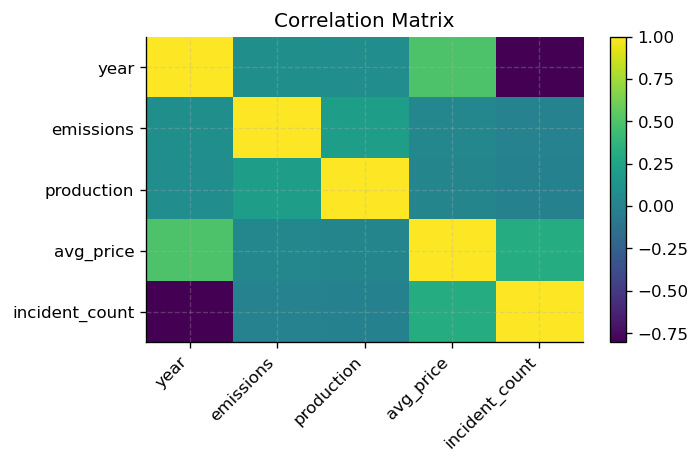

In [ ]:
# ==============================================
# 4) EDA -- Summary
# ==============================================
print(model_df.describe(include='all').T)
numeric_cols = model_df.select_dtypes(include='number').columns.tolist()
corr = model_df[numeric_cols].corr()
set_viz_style(); plt.figure(figsize=(6, 4))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Matrix')
plt.colorbar(); plt.tight_layout()
plt.savefig('figures/week0_correlation_matrix.png', dpi=200, bbox_inches='tight'); plt.show()
model_df.describe(include='all').T.to_csv('figures/eda_describe.csv')


OLS Baseline (pred-fold): {'R2': 0.040116390832404814, 'RMSE': 398.60032367459166, 'MAE': 150.88055787871033}
OLS Baseline (repeated-CV mean±std): {'R2_mean': 0.04020919704042838, 'R2_std': 0.007525745552774266, 'RMSE_mean': 397.68758184478713, 'RMSE_std': 27.253186148870455, 'MAE_mean': 150.89841551058282, 'MAE_std': 2.643072710652898}
OLS + Poly/Interactions (deg=2) (pred-fold): {'R2': 0.058496236501418886, 'RMSE': 394.7656801985701, 'MAE': 146.87175059103276}
OLS + Poly/Interactions (deg=2) (repeated-CV mean±std): {'R2_mean': 0.05892208960844595, 'R2_std': 0.007903199259929718, 'RMSE_mean': 393.80278465095296, 'RMSE_std': 27.163052535340896, 'MAE_mean': 146.92923364134123, 'MAE_std': 2.537683029234319}


,R2,RMSE,MAE
OLS,0.040116,398.600324,150.880558
OLS+Poly,0.058496,394.765680,146.871751


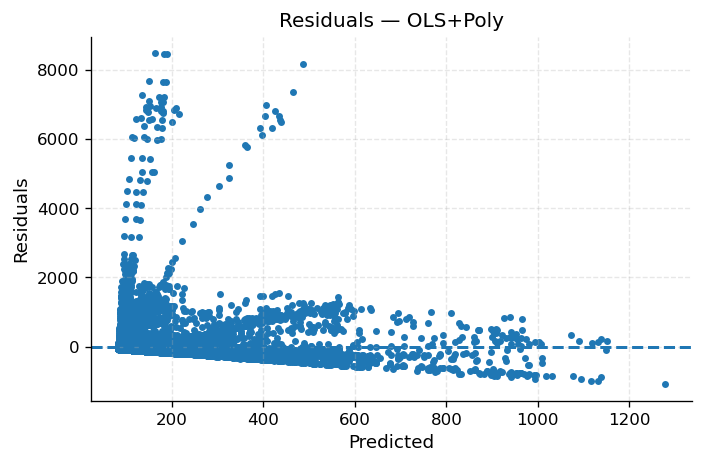

In [ ]:
# ==============================================
# 5) Week 1 — OLS vs OLS+Polynomial/Interactions  + Imputation
# ==============================================
from sklearn.model_selection import KFold, RepeatedKFold
TARGET = 'emissions'
FEATURES_BASE = [c for c in ['production','avg_price','incident_count'] if c in model_df.columns]
if not FEATURES_BASE:
    raise ValueError('No candidate predictors found. Ensure production/avg_price/incident_count exist after merge.')
X = model_df[FEATURES_BASE].copy(); y = model_df[TARGET].copy()
cv_pred = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rep  = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
def cv_regression_report(model, X, y, label='model'):
    y_hat = cross_val_predict(model, X, y, cv=cv_pred, n_jobs=1)
    metrics_pred = eval_regression(y, y_hat)
    r2 = cross_val_score(model, X, y, cv=cv_rep, scoring='r2', n_jobs=1)
    rmse = -cross_val_score(model, X, y, cv=cv_rep, scoring='neg_root_mean_squared_error', n_jobs=1)
    mae = -cross_val_score(model, X, y, cv=cv_rep, scoring='neg_mean_absolute_error', n_jobs=1)
    metrics_rep = {'R2_mean': float(r2.mean()), 'R2_std': float(r2.std()), 'RMSE_mean': float(rmse.mean()), 'RMSE_std': float(rmse.std()), 'MAE_mean': float(mae.mean()), 'MAE_std': float(mae.std())}
    print(label + ' (pred-fold):', metrics_pred)
    print(label + ' (repeated-CV mean±std):', metrics_rep)
    return metrics_pred, metrics_rep, y_hat
pipe_base = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('ols', LinearRegression())])
m_base_pred, m_base_rep, yhat_base = cv_regression_report(pipe_base, X, y, label='OLS Baseline')
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
pipe_poly = Pipeline([('imputer', SimpleImputer(strategy='median')), ('poly', poly), ('scaler', StandardScaler()), ('ols', LinearRegression())])
m_poly_pred, m_poly_rep, yhat_poly = cv_regression_report(pipe_poly, X, y, label='OLS + Poly/Interactions (deg=2)')
import pandas as pd
metrics_tbl = pd.DataFrame([m_base_pred, m_poly_pred], index=['OLS','OLS+Poly'])
display(metrics_tbl)
metrics_tbl.to_csv('figures/week1_metrics_table.csv')
best_label = metrics_tbl['RMSE'].idxmin()
best_pred = yhat_poly if best_label == 'OLS+Poly' else yhat_base
set_viz_style(); plt.figure(figsize=(6,4))
plt.scatter(best_pred, y - best_pred, s=10)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted'); plt.ylabel('Residuals'); plt.title('Residuals — ' + best_label)
plt.tight_layout(); plt.savefig('figures/week1_residuals.png', dpi=200, bbox_inches='tight'); plt.show()


In [ ]:
# ==============================================
# 5B) Week 1 — Enhancements
# ==============================================
from sklearn.model_selection import RepeatedKFold
TARGET = 'emissions'
FEATS = [c for c in ['production','avg_price','incident_count'] if c in model_df.columns]
X = model_df[FEATS].copy(); y = model_df[TARGET].copy()
use_log1p = (y.min() > 0) and all((X[c].min() > 0) for c in FEATS)
if use_log1p:
    import numpy as np
    X = np.log1p(X); y = np.log1p(y); print('Applied log1p to X and y')
cv_rep  = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
pipe_std = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('ols', LinearRegression())])
r2 = cross_val_score(pipe_std, X, y, cv=cv_rep, scoring='r2', n_jobs=1)
rmse = -cross_val_score(pipe_std, X, y, cv=cv_rep, scoring='neg_root_mean_squared_error', n_jobs=1)
mae = -cross_val_score(pipe_std, X, y, cv=cv_rep, scoring='neg_mean_absolute_error', n_jobs=1)
pd.DataFrame({'R2': r2, 'RMSE': rmse, 'MAE': mae}).describe().to_csv('figures/week1_repeatedcv_summary.csv')
print('Saved: figures/week1_repeatedcv_summary.csv')


Applied log1p to X and y
Saved: figures/week1_repeatedcv_summary.csv


c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.664e+09, tolerance: 3.461e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.590e+09, tolerance: 3.303e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linea

Nested CV — outer R² mean/std: 0.040027130687220726 0.007871797978979888
Saved: figures/week2_nested_cv_summary.json


c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.016e+09, tolerance: 4.188e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.039e+09, tolerance: 4.256e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linea

,coef
incident_count,-10.122509
avg_price,8.944814
production,79.359592


Saved: figures/week2_elasticnet_coefs.csv


c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.041e+09, tolerance: 4.256e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.010e+09, tolerance: 4.192e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linea

Elastic Net (KFold-pred) metrics: {'R2': 0.04011600984082475, 'RMSE': 398.6004027796783, 'MAE': 150.98813192788896}


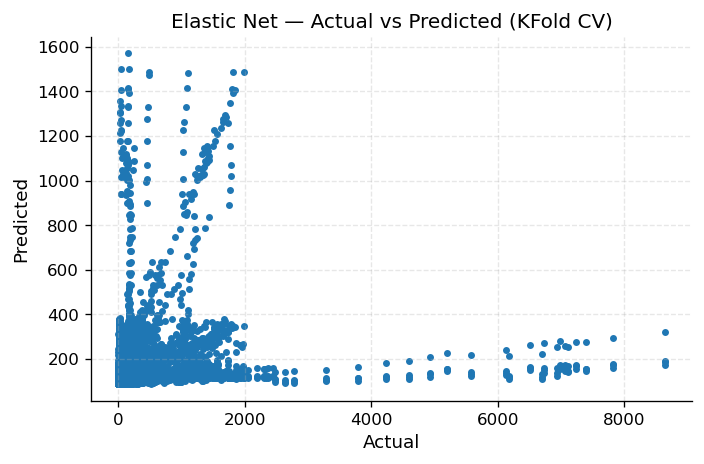

In [12]:
# ==============================================
# 6) Week 2 — Elastic Net (Ridge↔Lasso) with Nested CV + KFold/RepeatedKFold Diagnostics
# ==============================================
X = model_df[[c for c in ['production','avg_price','incident_count'] if c in model_df.columns]].copy()
y = model_df['emissions'].copy()
pipe_en = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('en', ElasticNet(max_iter=20000, random_state=RANDOM_STATE))])
param_grid = {'en__alpha': np.logspace(-4, 2, 12), 'en__l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0]}
outer_cv = KFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
inner_cv = KFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
outer_scores = []; best_params = []
for tr, te in outer_cv.split(X, y):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    gs = GridSearchCV(pipe_en, param_grid, cv=inner_cv, scoring='r2', n_jobs=1)
    gs.fit(X_tr, y_tr)
    y_hat = gs.best_estimator_.predict(X_te)
    outer_scores.append(r2_score(y_te, y_hat))
    best_params.append(gs.best_params_)
nested_summary = { 'outer_mean_R2': float(np.mean(outer_scores)), 'outer_std_R2': float(np.std(outer_scores)), 'samples': best_params[:5] }
print('Nested CV — outer R² mean/std:', nested_summary['outer_mean_R2'], nested_summary['outer_std_R2'])
with open('figures/week2_nested_cv_summary.json','w') as f:
    json.dump(nested_summary, f, indent=2)
print('Saved: figures/week2_nested_cv_summary.json')
gs_final = GridSearchCV(pipe_en, param_grid, cv=inner_cv, scoring='r2', n_jobs=1)
gs_final.fit(X, y)
best_en = gs_final.best_estimator_
coef_tbl = pd.Series(best_en.named_steps['en'].coef_, index=X.columns).to_frame('coef').sort_values('coef')
display(coef_tbl)
coef_tbl.to_csv('figures/week2_elasticnet_coefs.csv')
print('Saved: figures/week2_elasticnet_coefs.csv')
cv_pred = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_hat = cross_val_predict(best_en, X, y, cv=cv_pred, n_jobs=1)
metrics = eval_regression(y, y_hat)
print('Elastic Net (KFold-pred) metrics:', metrics)
pd.DataFrame([metrics]).to_csv('figures/week2_elasticnet_kfoldpred_metrics.csv', index=False)
set_viz_style(); plt.figure(figsize=(6,4))
plt.scatter(y, y_hat, s=10)
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Elastic Net — Actual vs Predicted (KFold CV)')
plt.tight_layout(); plt.savefig('figures/week2_actual_vs_pred_kfold.png', dpi=200, bbox_inches='tight'); plt.show()


In [13]:
# ==============================================
# 6B) Week 2 — Compare Ridge, Lasso, Elastic Net (Nested CV)
# ==============================================
X = model_df[[c for c in ['production','avg_price','incident_count'] if c in model_df.columns]].copy()
y = model_df['emissions'].copy()
pipes = {
  'Ridge': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('est', Ridge(random_state=RANDOM_STATE))]),
  'Lasso': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('est', Lasso(random_state=RANDOM_STATE, max_iter=20000))]),
  'ElasticNet': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('est', ElasticNet(random_state=RANDOM_STATE, max_iter=20000))])
}
grids = {
  'Ridge': {'est__alpha': np.logspace(-4,2,12)},
  'Lasso': {'est__alpha': np.logspace(-4,2,12)},
  'ElasticNet': {'est__alpha': np.logspace(-4,2,12), 'est__l1_ratio': [0.0, .2, .5, .8, 1.0]},
}
outer = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name in pipes:
    scores = []
    bests = []
    for tr, te in outer.split(X, y):
        gs = GridSearchCV(pipes[name], grids[name], cv=inner, scoring='r2', n_jobs=1)
        gs.fit(X.iloc[tr], y.iloc[tr])
        scores.append(gs.best_estimator_.score(X.iloc[te], y.iloc[te]))
        bests.append(gs.best_params_)
    rows.append({'model': name, 'outer_mean_R2': float(np.mean(scores)), 'outer_std_R2': float(np.std(scores)), 'best_samples': bests})
res_df = pd.DataFrame(rows)
display(res_df)
res_df.to_csv('figures/week2_nestedcv_ridge_lasso_en.csv', index=False)
print('Saved: figures/week2_nestedcv_ridge_lasso_en.csv')


c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.664e+09, tolerance: 3.461e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\CoryF\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.590e+09, tolerance: 3.303e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linea

,model,outer_mean_R2,outer_std_R2,best_samples
0,Ridge,0.040140,0.007936,"[{'est__alpha': 100.0}, {'est__alpha': 100.0},..."
1,Lasso,0.040038,0.007960,"[{'est__alpha': 0.6579332246575675}, {'est__al..."
2,ElasticNet,0.040027,0.007872,"[{'est__alpha': 0.05336699231206307, 'est__l1_..."


Saved: figures/week2_nestedcv_ridge_lasso_en.csv


In [14]:
# ==============================================
# 7) Reporting (current / will be moved)
# ==============================================
model_spec = {
  'features_used': [c for c in ['production','avg_price','incident_count'] if c in model_df.columns],
  'target': 'emissions',
  'preprocessing': ['median imputation', 'standardization'],
  'week1_models': ['OLS baseline', 'OLS + degree-2 polynomial interactions'],
  'week2_models': ['Ridge', 'Lasso', 'Elastic Net (nested CV)'],
  'cv': {
     'prediction_plots': 'KFold(5, shuffle=True)',
     'stability_scores': 'RepeatedKFold(5x5)',
     'model_selection': 'Nested CV (5 outer x 5 inner)'
  },
  'hyperparams_en': {'alpha': '1e-4..1e2 (logspace)', 'l1_ratio': [0.0,0.2,0.5,0.8,1.0]},
}
import json, pandas as pd
with open('figures/model_spec_week1_2.json','w') as f:
    json.dump(model_spec, f, indent=2)
pd.Series([
 'figures/model_df_preview.csv',
 'figures/eda_describe.csv',
 'figures/eda_missing_overall.csv',
 'figures/eda_missing_by_year.csv',
 'figures/eda_missing_by_year.png',
 'figures/eda_production_units_counts.csv',
 'figures/eda_commodity_counts.csv',
 'figures/eda_dist_emissions.png',
 'figures/eda_dist_production.png',
 'figures/eda_dist_avg_price.png',
 'figures/eda_dist_incident_count.png',
 'figures/eda_yearly_means.png',
 'figures/eda_vif.csv',
 'figures/week1_metrics_table.csv',
 'figures/week1_residuals.png',
 'figures/week1_repeatedcv_summary.csv',
 'figures/week2_nested_cv_summary.json',
 'figures/week2_elasticnet_coefs.csv',
 'figures/week2_elasticnet_kfoldpred_metrics.csv',
 'figures/week2_actual_vs_pred_kfold.png',
 'figures/week2_nestedcv_ridge_lasso_en.csv'
], name='artifact').to_csv('figures/exports_checklist.csv', index=False)
print('Saved: figures/model_spec_week1_2.json and figures/exports_checklist.csv')


Saved: figures/model_spec_week1_2.json and figures/exports_checklist.csv
